In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, correlate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, Bidirectional, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
# =========================
# STEP 1: LOAD DATA
# =========================
data = pd.read_csv('samples2.csv')
data.columns = data.columns.str.strip().str.replace("'", "").str.replace(" ", "")

def clean_signal(signal):
    cleaned = []
    for x in     signal:
        try:
            cleaned.append(float(str(x).replace("mV", "").strip()))
        except:
            continue
    return np.array(cleaned)

pleth = clean_signal(data['PLETH'].values[:15000])
abp   = clean_signal(data['ABP'].values[:15000])


C:\Users\abhis\AppData\Local\Temp\ipykernel_31148\2627414135.py:4: DtypeWarning: Columns (0,1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('samples2.csv')


In [51]:
# =========================
# STEP 2: WEIGHTED MOVING AVERAGE (4th ORDER)
# =========================
def weighted_moving_average(signal, window=5):
    weights = np.arange(1, window+1)
    return np.convolve(signal, weights/weights.sum(), mode='same')

pleth_filtered = weighted_moving_average(pleth, 5)

In [52]:
# =========================
# STEP 3: LATCH REMOVAL + ALIGN LENGTH
# =========================
min_len = min(len(pleth_filtered), len(abp))
pleth_filtered = pleth_filtered[:min_len]
abp = abp[:min_len]

In [53]:
# =========================
# STEP 4: SYNCHRONIZATION
# =========================
corr = correlate(pleth_filtered, abp, mode='full')
delay = np.argmax(corr) - len(abp) + 1

if delay > 0:
    pleth_sync = pleth_filtered[delay:]
    abp_sync   = abp[:-delay]
else:
    pleth_sync = pleth_filtered[:delay]
    abp_sync   = abp[-delay:]


In [54]:
# =========================
# STEP 5: ADVANCED FEATURE EXTRACTION
# =========================
def extract_features(signal):
    peaks, _ = find_peaks(signal, distance=30)
    features = []

    for i in range(1, len(peaks)-1):
        systolic = signal[peaks[i]]
        notch = np.min(signal[peaks[i]:peaks[i+1]])

        # Additional features
        time_diff = peaks[i+1] - peaks[i]
        amplitude = systolic - notch
        area = np.trapz(signal[peaks[i]:peaks[i+1]])

        features.append([systolic, notch, time_diff, amplitude, area])

    return np.array(features)

features = extract_features(pleth_sync)
abp_sync = abp_sync[:len(features)]

C:\Users\abhis\AppData\Local\Temp\ipykernel_31148\504047936.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(signal[peaks[i]:peaks[i+1]])


In [55]:
# =========================
# STEP 6: NORMALIZATION (BETTER)
# =========================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_norm = scaler_X.fit_transform(features)
y_norm = scaler_y.fit_transform(abp_sync.reshape(-1,1))

In [56]:
# =========================
# STEP 7: SEQUENCES (LONGER)
# =========================
def create_sequences(X, y, seq_len=50):
    Xs, ys = [], []
    for i in range(len(X)-seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X, y = create_sequences(X_norm, y_norm, 50)


In [57]:
# =========================
# STEP 8: REMOVE OUTLIERS
# =========================
mask = np.abs(y - np.mean(y)) < 3*np.std(y)
X = X[mask.flatten()]
y = y[mask.flatten()]

In [58]:
# =========================
# STEP 9: TRAIN TEST SPLIT
# =========================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [59]:
# =========================
# STEP 10: LSTM MODEL
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
model.summary()

c:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,241 (477.50 KB)

 Trainable params: 122,241 (477.50 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# =========================
# STEP 11: TRAINING
# =========================
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 2.3147 - val_loss: 2.7958
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 2.2280 - val_loss: 2.7227
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 2.1787 - val_loss: 2.6508
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 2.0675 - val_loss: 2.5653
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 2.0081 - val_loss: 2.4630
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 1.8203 - val_loss: 2.3466
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1.7665 - val_loss: 2.2102
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.6518 - val_loss: 2.0492
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 1.5206 - val_loss: 1.8589
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 1.4025 - val_loss: 1.6341
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.1724 - val_loss: 1.3711
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8872 - val_los

In [61]:
# =========================
# STEP 12: PREDICTION
# =========================
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


In [62]:
# =========================
# STEP 13: METRICS
# =========================
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
sd  = np.std(y_test_inv - y_pred_inv)

mse_norm = mean_squared_error(y_test, y_pred)
mae_norm = mean_absolute_error(y_test, y_pred)
sd_norm  = np.std(y_test - y_pred)

print("\n===== LSTM RESULTS =====")

print("\n--- Real Scale ---")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"SD  : {sd:.4f}")

print("\n--- Normalized (0–1) ---")
print(f"MSE (Norm): {mse_norm:.6f}")
print(f"MAE (Norm): {mae_norm:.6f}")
print(f"SD  (Norm): {sd_norm:.6f}")


===== LSTM RESULTS =====

--- Real Scale ---
MSE : 0.3268
MAE : 0.5717
SD  : 0.0000

--- Normalized (0–1) ---
MSE (Norm): 0.001935
MAE (Norm): 0.043992
SD  (Norm): 0.000000


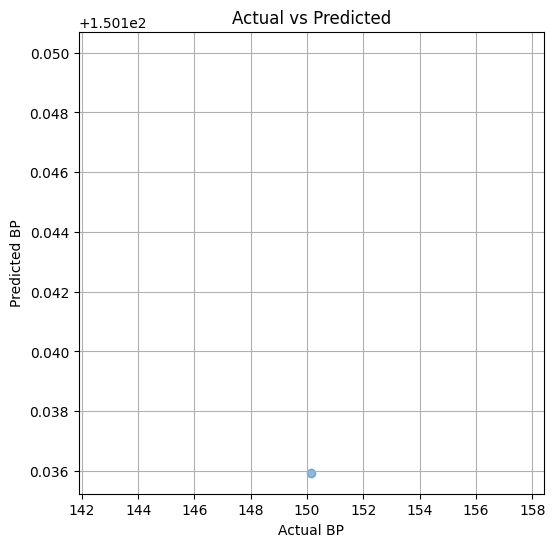

In [63]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_plot, y_pred_plot, alpha=0.5)

plt.xlabel("Actual BP")
plt.ylabel("Predicted BP")
plt.title("Actual vs Predicted")

# Perfect line
plt.plot([min(y_test_plot), max(y_test_plot)],
         [min(y_test_plot), max(y_test_plot)],
         color='red')

plt.grid()
plt.show()